In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from src.Utils import plot_performance_analysis
from src.NN_Utils import build_meta_neural_network
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Inspección de Hiperparámetros de Otros Modelos</h2>

In [4]:
model_nn1 = load_model('../models/MO_NeuralNetwork.keras')
model_nn2 = load_model('../models/MO_MetaGen_NeuralNetwork.keras')

In [5]:
def analyze_architecture(path_model):
    model = tf.keras.models.load_model(path_model)

    config_opt = model.optimizer.get_config()
    print(f"Optimizador: {config_opt.get('name')}")
    print(f"Learning Rate: {config_opt.get('learning_rate')}")

    activacion = "No encontrada explícitamente"
    dropout = "No encontrado"

    for layer in model.layers:
        class_layer = layer.__class__.__name__.lower()
        if 'activation' in class_layer:
            activacion = layer.get_config().get('activation')
        if 'dropout' in class_layer:
            dropout = layer.get_config().get('rate')
    print(f"Activación usada: {activacion}")
    print(f"Tasa de Dropout: {dropout}")
    print("-----------------------------------\n")

analyze_architecture('../models/MO_NeuralNetwork.keras')
analyze_architecture('../models/MO_MetaGen_NeuralNetwork.keras')

Optimizador: adam
Learning Rate: 0.0003497444558888674
Activación usada: elu
Tasa de Dropout: No encontrado
-----------------------------------

Optimizador: adam
Learning Rate: 0.0005000000237487257
Activación usada: elu
Tasa de Dropout: 0.2596563372571659
-----------------------------------



In [6]:
model_nn1.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_x             │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_349 (Dense)   │ (None, 96)        │      2,592 │ input_x[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_349      │ (None, 96)        │          0 │ dense_349[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_350 (Dense)   │ (None, 96)        │      9,312 │ activation_349[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_350      │ (None, 96)        │          0 │ dense_350[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_qgen7 (Dense)   │ (None, 1)         │         97 │ activation_350[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_51      │ (None, 27)        │          0 │ input_x[0][0],    │
│ (Concatenate)       │                   │            │ out_qgen7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_352 (Dense)   │ (None, 256)       │      7,168 │ concatenate_51[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_352      │ (None, 256)       │          0 │ dense_352[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_351 (Dense)   │ (None, 160)       │      4,480 │ concatenate_51[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_353 (Dense)   │ (None, 256)       │     65,792 │ activation_352[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_351      │ (None, 160)       │          0 │ dense_351[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_353      │ (None, 256)       │          0 │ dense_353[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_volt (Dense)    │ (None, 13)        │      2,093 │ activation_351[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_perd (Dense)    │ (None, 1)         │        257 │ activation_353[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,375 (1.05 MB)

 Trainable params: 91,791 (358.56 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 183,584 (717.13 KB)

In [7]:
model_nn2.summary()

Model: "functional_129"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_x             │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1224 (Dense)  │ (None, 149)       │      4,023 │ input_x[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1224     │ (None, 149)       │          0 │ dense_1224[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1224        │ (None, 149)       │          0 │ activation_1224[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1225 (Dense)  │ (None, 149)       │     22,350 │ dropout_1224[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1225     │ (None, 149)       │          0 │ dense_1225[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1225        │ (None, 149)       │          0 │ activation_1225[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1226 (Dense)  │ (None, 149)       │     22,350 │ dropout_1225[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1226     │ (None, 149)       │          0 │ dense_1226[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1226        │ (None, 149)       │          0 │ activation_1226[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1227 (Dense)  │ (None, 149)       │     22,350 │ dropout_1226[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1227     │ (None, 149)       │          0 │ dense_1227[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1227        │ (None, 149)       │          0 │ activation_1227[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1228 (Dense)  │ (None, 149)       │     22,350 │ dropout_1227[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1228     │ (None, 149)       │          0 │ dense_1228[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1228        │ (None, 149)       │          0 │ activation_1228[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_qgen7 (Dense)   │ (None, 1)         │        150 │ dropout_1228[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_129     │ (None, 27)        │          0 │ input_x[0][0],    │
│ (Concatenate)       │                   │            │ out_qgen7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1230 (Dense)  │ (None, 233)       │      6,524 │ concatenate_129[

 Total params: 969,320 (3.70 MB)

 Trainable params: 323,106 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 646,214 (2.47 MB)

<h2>Evaluación del Mejor Modelo</h2>

In [19]:
volts = len([c for c in Y.columns if c.startswith('V')])
idx_v = [Y.columns.get_loc(c) for c in Y.columns if c.startswith('V')]
idx_p = Y.columns.get_loc('PERD')
idx_q = Y.columns.get_loc('QGEN7')

In [20]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

xs_train = scaler_x.fit_transform(x_train)
ys_train = scaler_y.fit_transform(y_train)
xs_test = scaler_x.transform(x_test)

dict_y_train = {
    'out_volt': ys_train[:, idx_v],
    'out_perd': ys_train[:, idx_p:idx_p+1],
    'out_qgen7': ys_train[:, idx_q:idx_q+1]
}

In [8]:
hybrid_solution = {
    "activation": "elu",
    "dropout": 0.2596563372571659,
    "use_batch_norm": False,
    "learning_rate": 0.0005,
    "optimizer": "adam",
    "n_hidden_q": 5,
    "n_neurons_q": 149,
    "n_hidden_v": 1,
    "n_neurons_v": 114,
    "n_hidden_p": 2,
    "n_neurons_p": 256
}

In [22]:
hybrid_model = build_meta_neural_network(hybrid_solution, input_dim=x_train.shape[1], num_voltages=volts)
stop_early_final = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
hybrid_model.fit(xs_train, dict_y_train, epochs=50, batch_size=32, verbose=1, callbacks=[stop_early_final])

Epoch 1/50
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0724 - out_perd_loss: 0.0027 - out_perd_mae: 0.0358 - out_perd_mape: 129.5535 - out_perd_r2_score: 0.6376 - out_qgen7_loss: 0.0265 - out_qgen7_mae: 0.1178 - out_qgen7_mape: 8032.4277 - out_qgen7_r2_score: 0.3125 - out_volt_loss: 0.0138 - out_volt_mae: 0.0778 - out_volt_mape: 1471.1030 - out_volt_r2_score: 0.1031  
Epoch 2/50
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0333 - out_perd_loss: 5.5965e-04 - out_perd_mae: 0.0180 - out_perd_mape: 509.8925 - out_perd_r2_score: 0.9262 - out_qgen7_loss: 0.0152 - out_qgen7_mae: 0.0848 - out_qgen7_mape: 9895.9541 - out_qgen7_r2_score: 0.6062 - out_volt_loss: 0.0018 - out_volt_mae: 0.0330 - out_volt_mape: 1668.0730 - out_volt_r2_score: 0.8850
Epoch 3/50
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0264 - out_perd_loss: 3.8856e-04 - out_perd_mae: 0.0148 - out_perd_mape: 840.1371 - out_perd_r2_score: 0.9488 - out_qgen7_loss: 0.0124 - out_qgen7_mae: 0.0734 - out_qgen7_map

In [23]:
preds_list = hybrid_model.predict(xs_test)
preds_concat = np.hstack([preds_list[0], preds_list[1], preds_list[2]])
predictions = scaler_y.inverse_transform(preds_concat)

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step


In [24]:
random_MAE = mean_absolute_error(y_test, predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, predictions, multioutput='raw_values')

# DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, predictions, multioutput='raw_values')

In [25]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001843,0.001858,0.001866,0.001867,0.001867,0.001869,0.001869,0.001869,0.001869,0.001870,0.001871,0.001384,0.001385,0.220959,0.010801
MAPE,0.000934,0.000942,0.000946,0.000947,0.000947,0.000948,0.000948,0.000947,0.000948,0.000948,0.000949,0.000699,0.000699,0.025150,0.010080
R2,0.969961,0.969955,0.969983,0.969977,0.969984,0.969980,0.969902,0.969941,0.969946,0.969928,0.969908,0.978913,0.978903,0.980091,0.861613


In [26]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001843,0.001858,0.001866,0.001867,0.001867,0.001869,0.001869,0.001869,0.001869,0.001870,0.001871,0.001384,0.001385,0.220959,1.080100e-02
MAPE,0.001894,0.001910,0.001919,0.001920,0.001921,0.001923,0.001923,0.001922,0.001922,0.001924,0.001924,0.001411,0.001411,0.029531,1.518766e+13
R2,0.969961,0.969955,0.969983,0.969977,0.969984,0.969980,0.969902,0.969941,0.969946,0.969928,0.969908,0.978913,0.978903,0.980091,8.616129e-01


In [27]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001791,0.220959,0.010801
MAPE,0.000908,0.025150,0.010080
R2,0.971330,0.980091,0.861613


In [28]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001791,0.220959,1.080100e-02
MAPE,0.001840,0.029531,1.518766e+13
R2,0.971330,0.980091,8.616129e-01


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [29]:
hybrid_model.save('../models/MO_Hybrid_NeuralNetwork.keras')
joblib.dump(scaler_x, '../models/normalizers/MO_Hybrid_NeuralNetwork_Normalizer_x.pkl')
joblib.dump(scaler_y, '../models/normalizers/MO_Hybrid_NeuralNetwork_Normalizer_y.pkl')

['../models/normalizers/MO_Hybrid_NeuralNetwork_Normalizer_y.pkl']

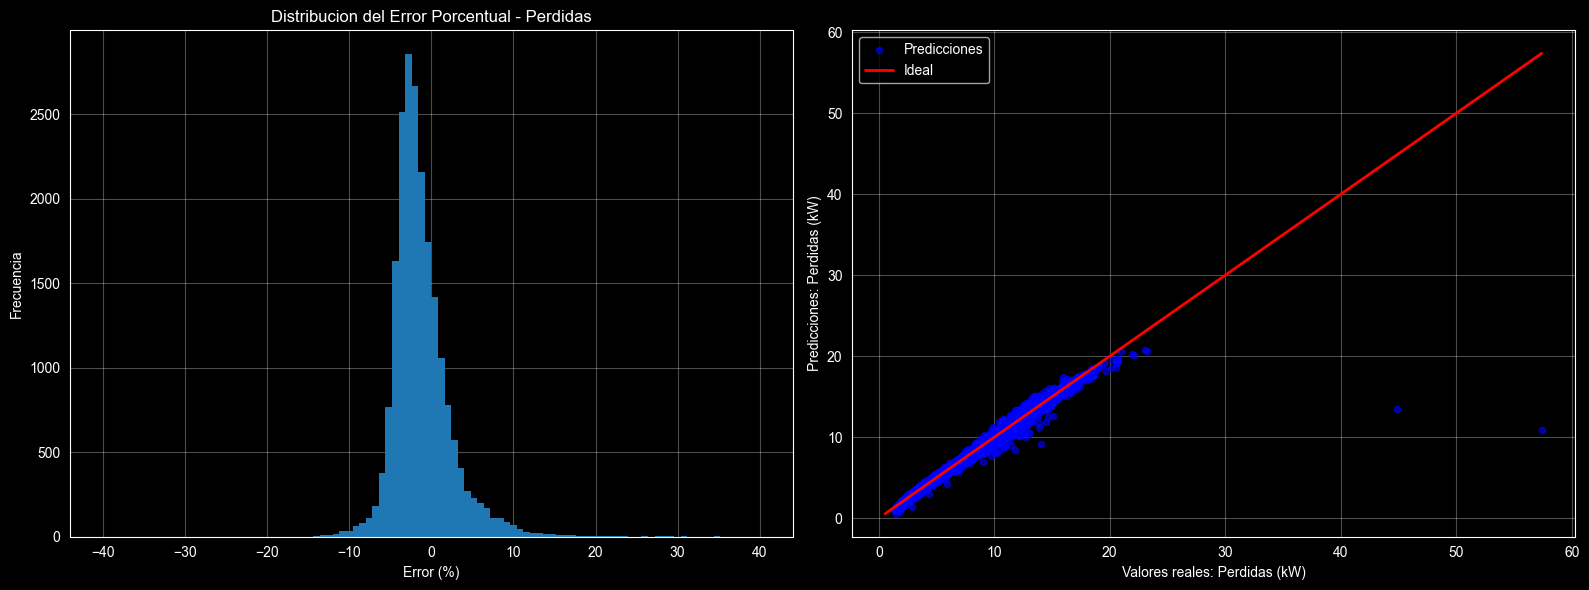

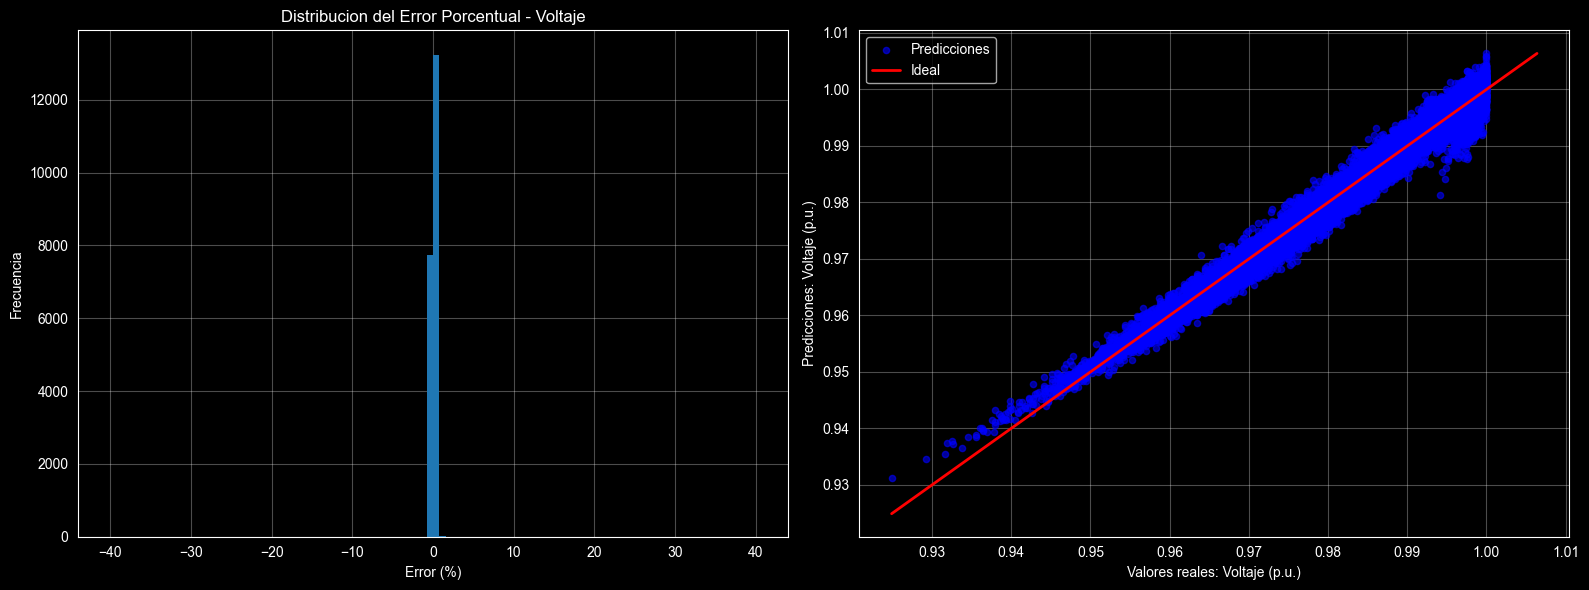

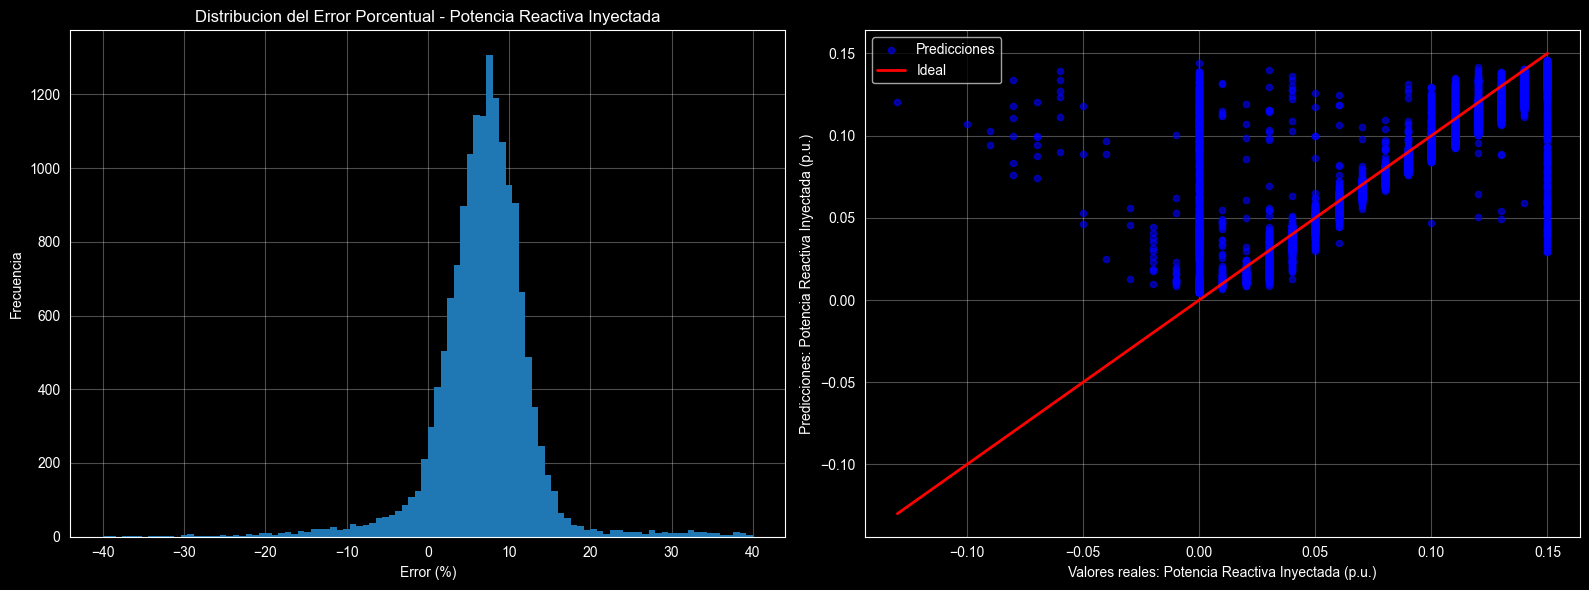

In [30]:
plot_performance_analysis(
    y_test['PERD'],
    predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_Hybrid_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_Hybrid_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_Hybrid_NeuralNetwork_QGen.png'
)